In [1]:
# Ячейка № 1

# подключение библиотеки numpy
import numpy as np

# подключение генератора случайных чисел
import random

# подключение пакета matplotlib.pyplot
import matplotlib.pyplot as plt

In [2]:
# Ячейка № 2

# инициализация генератора случайных чисел
random.seed()


# задание функции,
# возвращающей значения начальных
# координат броуновских частиц
def Init2(N_particle, R):
    # N_particle - число броуновских частиц
    # R - радиус круга, в котором размещаются
    #     броуновской частицы
    #     в момент времени t = 0

    # инициализация массива XY,
    # используемого для хранения
    # координат ансамбля броуновских частиц
    # в момент времени t = 0
    XY = np.zeros([N_particle, 2])

    for i in range(N_particle):
        # задание случайного значения
        # радиуса-вектора
        # i-ой броуновской частицы
        R0 = random.uniform(-R, R)
        # задание случайного значения
        # угла между осью абсцисс и
        # радиусом-вектором i-ой
        # броуновской частицы
        # в момент времени t = 0
        Teta = random.uniform(0, 2 * np.pi)

        # вычисление абсциссы
        # радиуса-вектора i-ой
        # броуновской частицы
        # в момент времени t = 0
        XY[i, 0] = R0 * np.cos(Teta)

        # вычисление абсциссы
        # радиуса-вектора i-ой
        # броуновской частицы
        # в момент времени t = 0
        XY[i, 1] = R0 * np.sin(Teta)

    return XY

In [3]:
# Ячейка № 2

# задание функции,
# возвращающей ансамбль
# координат случайных блужданий
# на двумерной плоскости


def Move(A, N_particle, N_step):
    # A - массив, возвращенный функцией Inti2
    # N_particle - число броуновских частиц
    # N_step - число шагов метода Монет-Карло

    # инициализация трехмерного массива XY
    # размерностью N_particle x 2 x N_step,
    # используемого для хранения мгновенных координат
    # ансамбля броуновских частиц на
    # на каждом шаге метода Монте-Карло
    XY = np.zeros([N_particle, 2, N_step + 1])

    # размещение координат
    # стартовой конфигурации
    # броуновских частиц в массив XY
    XY[:, :, 0] = A

    # программная реализация алгоритма
    # метода Монте-Карло
    for j in range(1, N_step + 1):
        for i in range(N_particle):
            Prob = random.uniform(0, 1)
            if Prob <= 0.25:
                XY[i, 0, j] = XY[i, 0, j - 1] + 1
                XY[i, 1, j] = XY[i, 1, j - 1]
            if (Prob > 0.25) & (Prob <= 0.5):
                XY[i, 0, j] = XY[i, 0, j - 1] - 1
                XY[i, 1, j] = XY[i, 1, j - 1]
            if (Prob > 0.5) & (Prob <= 0.75):
                XY[i, 0, j] = XY[i, 0, j - 1]
                XY[i, 1, j] = XY[i, 1, j - 1] - 1
            if Prob > 0.75:
                XY[i, 0, j] = XY[i, 0, j - 1]
                XY[i, 1, j] = XY[i, 1, j - 1] + 1
    return XY

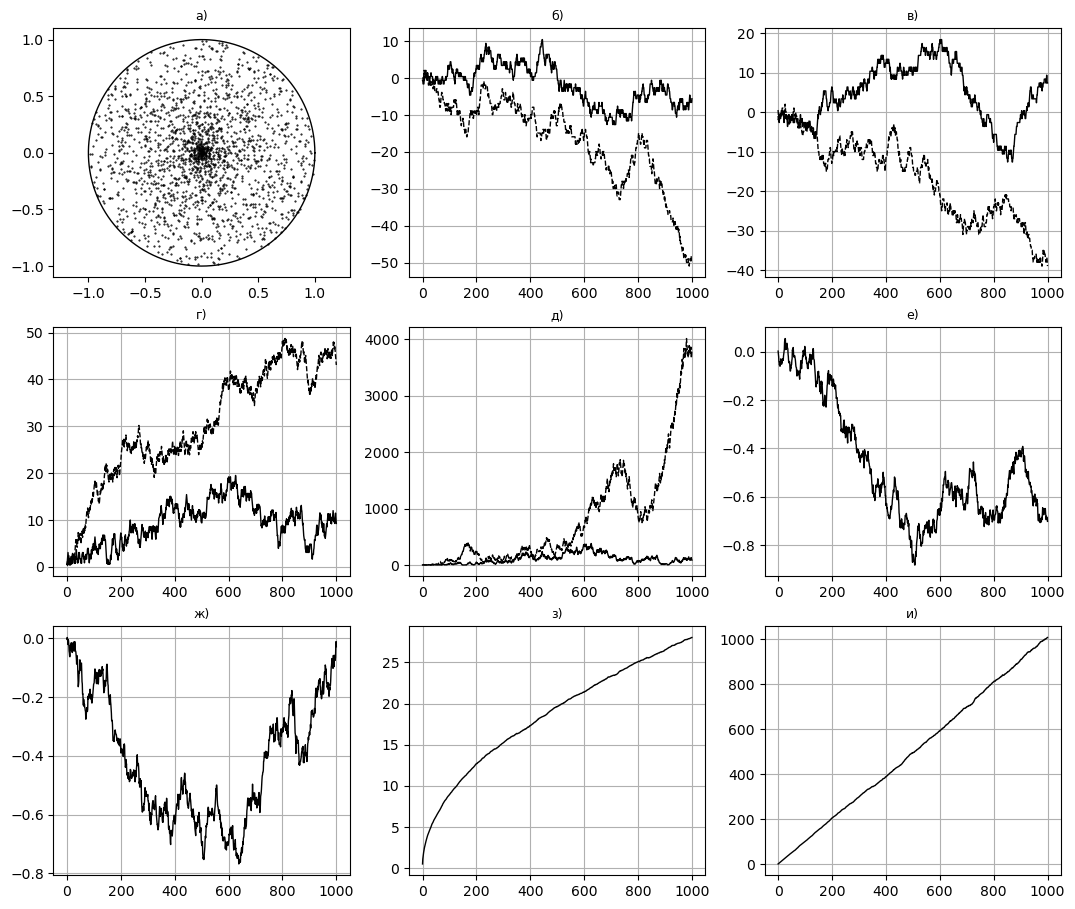

In [ ]:
# Ячейка № 3

# визуализация начального
# положения броуновских частиц
# характеристик их движения

# задание числа частиц системы
N_particle = 2 * 10**3

# задание числа шагов
# метода Монте-Карло
N_step = 10**3

# задание радиуса круга,
# внутри которого в момент времени
# t = 0 случайным образом размещаются
# броуновские частицы
R = 1

# инициализация стартовой конфигурации
# броуновских частиц
A = Init2(N_particle, R)

# вычисление ансамбля траекторий
# броуновских частиц
Am = Move(A, N_particle, N_step)

# визуализация результатов моделирования
# случайных броуновских блужданий
# на двумерной плоскости

fig = plt.figure(figsize=(13, 11))

# визуализация начального положения
# броуновских частиц
ax = plt.subplot(3, 3, 1)
plt.scatter(Am[:, 0, 0], Am[:, 1, 0], color="black", marker=".", s=1)
dphi = np.linspace(0, 2 * np.pi, 1000)
x = R * np.cos(dphi)
y = R * np.sin(dphi)
plt.plot(x, y, "-k", lw=1)
ax.set_title("а)", fontsize=9)
plt.axis("equal")

# визуализация последовательности,
# составленной из мгновенных значений
# абсцисс первой и 1000-й броуновских частиц
ax = plt.subplot(3, 3, 2)
plt.plot(Am[0, 0, :], "-k", lw=1)
plt.plot(Am[999, 0, :], "--k", lw=1)
ax.grid(True)
ax.set_title("б)", fontsize=9)

# визуализация последовательности,
# составленной из мгновенных значений
# ординат первой и 1000-й броуновских частиц
ax = plt.subplot(3, 3, 3)
plt.plot(Am[0, 1, :], "-k", lw=1)
plt.plot(Am[999, 1, :], "--k", lw=1)
ax.grid(True)
ax.set_title("в)", fontsize=9)

# визуализация последовательности,
# составленной из мгновенных значений
# длин радиусов-векторов
# первой и 1000-й броуновских частиц
ax = plt.subplot(3, 3, 4)
ax.plot(np.sqrt(Am[0, 0, :] ** 2 + Am[0, 1, :] ** 2), "-k", lw=1)
ax.plot(np.sqrt(Am[1000, 0, :] ** 2 + Am[1000, 1, :] ** 2), "--k", lw=1)
ax.grid(True)
ax.set_title("г)", fontsize=9)

# визуализация последовательности,
# составленной из мгновенных значений
# квадрата модуля радиуса-вектора
# первой и 1000-й броуновских частиц
ax = plt.subplot(3, 3, 5)
ax.plot(Am[0, 0, :] ** 2 + Am[0, 1, :] ** 2, "-k", lw=1)
ax.plot(Am[999, 0, :] ** 2 + Am[999, 1, :] ** 2, "--k", lw=1)
ax.grid(True)
ax.set_title("д)", fontsize=9)

# визуализация последовательности,
# составленной из мгновенных значений
# абсцисс броуновских частиц, усредненных
# по всем частицам
ax = plt.subplot(3, 3, 6)
ax.plot(np.mean(Am[:, 0, :], axis=0), "-k", lw=1)
ax.grid(True)
ax.set_title("е)", fontsize=9)

# визуализация последовательности,
# составленной из мгновенных значений
# ординат броуновских частиц, усредненных
# по всем частицам
ax = plt.subplot(3, 3, 7)
ax.plot(np.mean(Am[:, 1, :], axis=0), "-k", lw=1)
ax.grid(True)
ax.set_title("ж)", fontsize=9)

# визуализация последовательности,
# составленной из мгновенных значений
# длин радиусов-векторов броуновских частиц,
# усредненных по всем частицам
ax = plt.subplot(3, 3, 8)
ax.plot(np.mean(np.sqrt(Am[:, 0, :] ** 2 + Am[:, 1, :] ** 2), axis=0), "-k", lw=1)
ax.grid(True)
ax.set_title("з)", fontsize=9)

# визуализация последовательности,
# составленной из мгновенных значений
# квадратов длин радиусов-векторов
# броуновских частиц,
# усредненных по всем частицам
ax = plt.subplot(3, 3, 9)
ax.plot(np.mean((Am[:, 0, :] ** 2 + Am[:, 1, :] ** 2), axis=0), "-k", lw=1)
ax.grid(True)
ax.set_title("и)", fontsize=9)

plt.show()